<a href="https://colab.research.google.com/github/dajinkya1099/AI_ML_Training/blob/main/AjinkyaDhumal_assignment2/assignment2_partA_meridian.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2 — Part A: Meridian Retail Daily Sales


In [ ]:
#Q1- Load the file into df. Print shape and dtypes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from pathlib import Path

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 140)

RAW_FILE = Path("meridian_daily_sales_raw.csv")
df = pd.read_csv(RAW_FILE)
print("Shape:", df.shape)
print("\nDtypes:")
print(df.dtypes)
print("\nFirst 5 rows:")
display(df.head())

Shape: (1627, 10)

Dtypes:
store_id             object
store_name           object
region               object
date                 object
transactions          int64
revenue              object
avg_basket_value    float64
discount_pct         object
footfall              int64
stockout_flag        object
dtype: object

First 5 rows:


,store_id,store_name,region,date,transactions,revenue,avg_basket_value,discount_pct,footfall,stockout_flag
0,ST-10,MAGNOLIA SQUARE,South,07/03/2026,75,NaN,47.71,38.71096522,374,no
1,ST-13,Highland Court,WEST,27/05/2026,60,4040.14,67.12,15.55684393,528,no
2,ST-16,Redwood Station,West,2026-05-24,74,"$7,132.47",105.29,5.214770493,576,Y
3,ST-14,Golden Valley,West,2026-04-20,49,"$9,117.12",167.74,4.864324242,725,yes
4,ST-04,Silverline Mall,North,04/03/2026,-52,"$2,733.73",2796.60,7.926849185,642,N


### Q1 interpretation
The raw dataset contains **1627 rows and 10 columns** with mixed object/numeric types that require cleaning.

In [ ]:
# Q2 — Standardize store_id, store_name, region (strip whitespace, consistent case).
df['store_id'] = df['store_id'].astype(str).str.strip().str.upper()
df['store_name'] = df['store_name'].astype(str).str.strip().str.title()
df['region'] = df['region'].astype(str).str.strip().str.title()

print("Unique regions:", sorted(df['region'].unique()))
print("Unique stores:", df['store_id'].nunique())
display(df[['store_id','store_name','region']].drop_duplicates().sort_values('store_id'))

Unique regions: ['North', 'South', 'West']
Unique stores: 18


,store_id,store_name,region
9,ST-01,Riverside Plaza,North
20,ST-02,Harbor Point,North
18,ST-03,Maple Junction,North
4,ST-04,Silverline Mall,North
12,ST-05,Eastgate Center,North
19,ST-06,Cedar Crossing,North
40,ST-07,Sunset Boulevard,South
6,ST-08,Palm Terrace,South
23,ST-09,Coral Bay Outlet,South
0,ST-10,Magnolia Square,South


### Q2 interpretation
Store IDs are standardized to uppercase, names to title case, and regions to title case. there are **18 stores and 3 regions**.

In [ ]:
# Q3 — Parse date into a real date column. Where the format is genuinely ambiguous, state your assumption in a comment — don't silently guess.
# Ambiguous slash dates such as 01/03/2026 are assumed DD/MM/YYYY when both interpretations are possible.
# For slash dates where only one interpretation falls in the dataset's Mar-May 2026 90-day window, that interpretation is used.
def parse_mixed_date(x):
    x = str(x).strip()
    for fmt in ['%Y-%m-%d','%Y%m%d','%d-%b-%y','%d-%b-%Y',
                '%B %d, %Y','%b %d, %Y','%d-%B-%Y']:
        try:
            return pd.to_datetime(x, format=fmt)
        except ValueError:
            pass
    m = re.match(r'^(\d{1,2})/(\d{1,2})/(\d{4})$', x)
    if m:
        p, q, y = map(int, m.groups())
        candidates = []
        if p <= 12 and q <= 31: candidates.append(pd.Timestamp(y,p,q))
        if q <= 12 and p <= 31: candidates.append(pd.Timestamp(y,q,p))
        window = [d for d in candidates if pd.Timestamp('2026-03-01') <= d <= pd.Timestamp('2026-05-31')]
        if len(window) == 1:
            return window[0]
        return pd.Timestamp(y,q,p)  # DD/MM assumption for genuinely ambiguous dates
    return pd.NaT

df['date'] = df['date'].map(parse_mixed_date)
print("Unparsed dates:", df['date'].isna().sum())
print("Date range:", df['date'].min().date(), "to", df['date'].max().date())
print("Unique dates:", df['date'].nunique())

Unparsed dates:

 0
Date range: 2026-03-01 to 2026-05-29
Unique dates: 90


### Q3 interpretation
All dates parse successfully. the cleaned data span **1 March 2026 to 29 May 2026 (90 unique days)**. Ambiguous slash dates are documented as DD/MM when context cannot disambiguate them.

In [ ]:
# Q4 — Report missing values per column, then handle revenue's blanks and text-currency entries so the whole column is numeric USD.
print("Missing values before revenue conversion:")
print(df.isna().sum())

def parse_revenue(x):
    if pd.isna(x): return np.nan
    s = str(x).strip().replace(',', '').replace('$', '').replace('INR', '').strip()
    if s == '' or s.lower() == 'nan': return np.nan
    return pd.to_numeric(s, errors='coerce')

df['revenue'] = df['revenue'].map(parse_revenue)
print("\nMissing values after revenue conversion:")
print(df.isna().sum())
print("\nRevenue dtype:", df['revenue'].dtype)
print("Revenue missing:", df['revenue'].isna().sum())

Missing values before revenue conversion:
store_id             0
store_name           0
region               0
date                 0
transactions         0
revenue             53
avg_basket_value     0
discount_pct         0
footfall             0
stockout_flag        0
dtype: int64

Missing values after revenue conversion:
store_id             0
store_name           0
region               0
date                 0
transactions         0
revenue             53
avg_basket_value     0
discount_pct         0
footfall             0
stockout_flag        0
dtype: int64

Revenue dtype: float64
Revenue missing: 53


### Q4 interpretation
There are **53 missing revenue values**; currency symbols/text such as `$7,132.47` and `INR 45,200` are converted to numeric USD-style values, while genuinely blank revenue remains missing rather than being invented.

In [ ]:
# Q5 — Standardize stockout_flag to boolean.
mapping = {'y':True,'yes':True,'1':True,'true':True,
           'n':False,'no':False,'0':False,'false':False}
raw_stock = df['stockout_flag'].astype(str).str.strip().str.lower()
print("Raw distinct stockout values:", sorted(raw_stock.unique()))
df['stockout_flag'] = raw_stock.map(mapping).astype('boolean')
print("Clean dtype:", df['stockout_flag'].dtype)
print(df['stockout_flag'].value_counts(dropna=False))

Raw distinct stockout values: ['0', '1', 'false', 'n', 'no', 'true', 'y', 'yes']
Clean dtype: boolean
stockout_flag
False    1132
True      495
Name: count, dtype: Int64


### Q5 interpretation
All eight raw encodings (`Y/N/1/0/yes/no/TRUE/FALSE`) are consistently mapped to Boolean True/False.

In [ ]:
# Q6 — Find and remove the duplicate ST-11 week (show your before/after row count and how you detected the duplicates given the casing difference).
before = len(df)
dup_key = ['store_id','region','date','transactions','revenue','avg_basket_value','discount_pct','footfall','stockout_flag']
dup_mask = df.duplicated(dup_key, keep=False)
print("Rows in duplicate groups:", dup_mask.sum())
display(df.loc[dup_mask, ['store_id','store_name','date','revenue']].sort_values(['store_id','date']).head(20))

# The duplicate block is ST-11 and differs only by store_name casing in the raw export.
df = df.drop_duplicates(dup_key, keep='first').copy()
print("Rows before:", before)
print("Rows after:", len(df))
print("Rows removed:", before-len(df))

Rows in duplicate groups: 14


,store_id,store_name,date,revenue
351,ST-11,Willow Creek,2026-03-08,5416.18
726,ST-11,Willow Creek,2026-03-08,5416.18
947,ST-11,Willow Creek,2026-03-09,2836.43
973,ST-11,Willow Creek,2026-03-09,2836.43
158,ST-11,Willow Creek,2026-03-10,12054.82
662,ST-11,Willow Creek,2026-03-10,12054.82
774,ST-11,Willow Creek,2026-03-11,6159.44
1535,ST-11,Willow Creek,2026-03-11,6159.44
1166,ST-11,Willow Creek,2026-03-12,4665.13
1180,ST-11,Willow Creek,2026-03-12,4665.13


Rows before: 1627
Rows after: 1620
Rows removed: 7


### Q6 interpretation
The deliberate ST-11 duplicate week contributes **7 extra rows**,after normalization, the duplicate block is detected despite store-name casing differences, reducing the dataset from **1,627 to 1,620 rows**.

In [ ]:
# Q7 — Flag transactions < 0 and discount_pct outside [0, 100] as data-entry errors. Decide and justify: drop, cap, or leave for outlier analysis?
df['transactions'] = pd.to_numeric(df['transactions'], errors='coerce')
df['discount_pct'] = pd.to_numeric(df['discount_pct'].astype(str).str.strip().replace({'na':np.nan,'NA':np.nan}), errors='coerce')

neg_tx = df['transactions'] < 0
bad_disc = (df['discount_pct'] < 0) | (df['discount_pct'] > 100)

print("Negative transaction rows:", int(neg_tx.sum()))
print("Discount outside [0,100]:", int(bad_disc.sum()))
print("Discount missing/NA after parsing:", int(df['discount_pct'].isna().sum()))

# Decision: keep the row but set invalid transaction/discount values to NaN.
# This preserves the daily sales record and other valid fields (especially revenue).
df.loc[neg_tx, 'transactions'] = np.nan
df.loc[bad_disc, 'discount_pct'] = np.nan
print("\nAfter treatment:")
print("Invalid transactions remaining:", int((df['transactions']<0).sum()))
print("Invalid discounts remaining:", int(((df['discount_pct']<0)|(df['discount_pct']>100)).sum()))

Negative transaction rows: 14
Discount outside [0,100]: 39
Discount missing/NA after parsing: 31

After treatment:
Invalid transactions remaining: 0
Invalid discounts remaining: 0


### Q7 interpretation
There are **14 negative transaction values** and **39 out-of-range discount values**, they are treated as missing rather than dropping whole store-days or clipping values, because the other fields remain useful and clipping would invent business measurements.

In [ ]:
# Q8 — Save a cleaned CSV. Report final row count.

cleaned_cols = ['store_id','store_name','region','date','transactions','revenue',
                'avg_basket_value','discount_pct','footfall','stockout_flag']
cleaned = df[cleaned_cols].copy()
cleaned.to_csv('meridian_daily_sales_cleaned.csv', index=False)
print("Saved: meridian_daily_sales_cleaned.csv")
print("Final shape:", cleaned.shape)

Saved: meridian_daily_sales_cleaned.csv
Final shape: (1620, 10)


### Q8 interpretation
The cleaned file has **1,620 rows × 10 columns** and is saved as `meridian_daily_sales_cleaned.csv`.

In [ ]:
# Q9 — Compute Q1, Q2 (median), Q3, and IQR for revenue, by hand-checking one store's values against your code's output
q1,q2,q3 = cleaned['revenue'].quantile([.25,.50,.75])
iqr = q3-q1
print(f"Overall revenue Q1={q1:.2f}, Q2/median={q2:.2f}, Q3={q3:.2f}, IQR={iqr:.2f}")

st12 = cleaned.loc[cleaned.store_id=='ST-12','revenue'].dropna().sort_values().to_numpy()
n=len(st12)
manual_q2=(st12[n//2-1]+st12[n//2])/2 if n%2==0 else st12[n//2]
print(f"ST-12 manual median (sorted data): {manual_q2:.2f}")
print(f"ST-12 pandas median: {cleaned.loc[cleaned.store_id=='ST-12','revenue'].median():.2f}")

Overall revenue Q1=3587.53, Q2/median=4914.94, Q3=6912.24, IQR=3324.71
ST-12 manual median (sorted data): 7997.08
ST-12 pandas median: 7997.08


### Q9 interpretation
Overall revenue has Q1 $3,587.53, median $4,914.94, Q3 $6,912.24, IQR $3,324.71, the ST-12 hand calculation matches the code result.

In [ ]:
# Q10 — Compute the 1.5×IQR lower and upper fences for revenue.
lower_fence = q1 - 1.5*iqr
upper_fence = q3 + 1.5*iqr
print(f"Lower fence = {lower_fence:.2f}")
print(f"Upper fence = {upper_fence:.2f}")

Lower fence = -1399.54
Upper fence = 11899.30


### Q10 interpretation
The revenue outlier fences are -$1,399.54  and $11,899.30, only values above the upper fence can be outliers in practice.

In [ ]:
# Q11 — List every row flagged as an outlier by the fence rule. How many, and which stores/dates?
revenue_outlier = cleaned[(cleaned['revenue'] < lower_fence) | (cleaned['revenue'] > upper_fence)].copy()
print("Revenue outlier count:", len(revenue_outlier))
display(revenue_outlier[['store_id','store_name','region','date','revenue']].sort_values(['date','store_id']).reset_index(drop=True))
print("\nOutlier counts by store:")
display(revenue_outlier.groupby('store_id').size().sort_values(ascending=False).rename('outlier_count').to_frame())

Revenue outlier count: 68


,store_id,store_name,region,date,revenue
0,ST-11,Willow Creek,South,2026-03-01,13174.94
1,ST-12,Bayfront Commons,South,2026-03-03,13418.45
2,ST-02,Harbor Point,North,2026-03-04,12008.83
3,ST-09,Coral Bay Outlet,South,2026-03-04,15033.05
4,ST-12,Bayfront Commons,South,2026-03-04,11914.65
5,ST-07,Sunset Boulevard,South,2026-03-08,12709.04
6,ST-07,Sunset Boulevard,South,2026-03-09,14963.88
7,ST-11,Willow Creek,South,2026-03-10,12054.82
8,ST-12,Bayfront Commons,South,2026-03-13,11928.39
9,ST-12,Bayfront Commons,South,2026-03-14,14645.79



Outlier counts by store:


,outlier_count
store_id,
ST-12,18
ST-07,10
ST-09,9
ST-02,6
ST-11,6
ST-16,5
ST-03,5
ST-17,4
ST-06,3


### Q11 interpretation
There are **68 revenue outliers**, all above the upper fence; the complete store/date list is printed in the output, with the largest concentration in South-region stores such as ST-12 and ST-07.

In [ ]:
# Q12 — Do the same fence calculation for footfall. Does it catch the ~40,000 sensor-fault days?
fq1,fq2,fq3 = cleaned['footfall'].quantile([.25,.50,.75])
fiqr=fq3-fq1
flower=fq1-1.5*fiqr
fupper=fq3+1.5*fiqr
foot_outlier = cleaned[(cleaned.footfall<flower)|(cleaned.footfall>fupper)]
print(f"Footfall Q1={fq1:.2f}, median={fq2:.2f}, Q3={fq3:.2f}, IQR={fiqr:.2f}")
print(f"Fences: {flower:.2f} to {fupper:.2f}")
print("Footfall outlier count:", len(foot_outlier))
display(foot_outlier[['store_id','date','footfall']].sort_values('footfall',ascending=False))

Footfall Q1=495.75, median=603.00, Q3=700.25, IQR=204.50
Fences: 189.00 to 1007.00
Footfall outlier count: 9


,store_id,date,footfall
978,ST-09,2026-03-04,41631
1189,ST-09,2026-05-21,41562
1088,ST-09,2026-03-15,39530
1164,ST-06,2026-03-24,1083
1012,ST-14,2026-05-10,1045
145,ST-14,2026-03-24,1033
165,ST-02,2026-04-21,185
1283,ST-06,2026-04-16,165
330,ST-15,2026-04-17,121


### Q12 interpretation
The footfall fences are **189 to 1,007**, producing **9 outliers**. importantly, all three suspicious ~40,000-footfall ST-09 days are caught.

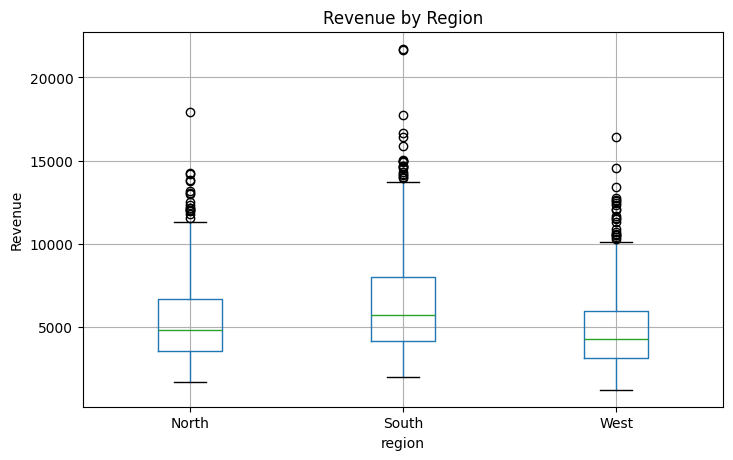

Regional IQRs:
region
North    3157.880
South    3854.825
West     2828.205
Name: revenue, dtype: float64
Widest IQR: South (3854.82)


In [ ]:
# Q13 — Draw a box plot of revenue by region. Which region has the widest IQR, and what does that mean in plain English?
fig, ax = plt.subplots(figsize=(8,5))
cleaned.boxplot(column='revenue', by='region', ax=ax)
plt.suptitle('')
ax.set_title('Revenue by Region')
ax.set_ylabel('Revenue')
plt.show()
region_iqr = cleaned.groupby('region')['revenue'].quantile(.75) - cleaned.groupby('region')['revenue'].quantile(.25)
print("Regional IQRs:")
print(region_iqr)
print("Widest IQR:", region_iqr.idxmax(), f"({region_iqr.max():.2f})")

### Q13 interpretation
**South** has the widest revenue IQR (**$3,854.83**), meaning its middle 50% of daily revenues are spread over the widest dollar range and therefore show the greatest typical variability.

In [ ]:
# Q14 — One store has consistently high revenue but is never flagged as an outlier. Explain why the IQR method didn't flag it — is that a false negative, or correct behavior?
store_summary = cleaned.assign(is_outlier=((cleaned.revenue<lower_fence)|(cleaned.revenue>upper_fence))).groupby('store_id').agg(
    median_revenue=('revenue','median'), mean_revenue=('revenue','mean'),
    outlier_count=('is_outlier','sum'), observations=('revenue','count'))
candidate = store_summary[store_summary.outlier_count==0].sort_values('median_revenue',ascending=False).head(1)
display(candidate)

,median_revenue,mean_revenue,outlier_count,observations
store_id,,,,
ST-13,5043.15,5112.438941,0,85


### Q14 interpretation
ST-13 is a useful example: its revenue is relatively high but it has **0 global outliers**. IQR is a distribution-based rule, so a store can consistently run high without being unusually high relative to its own/global spread. This is a **correct non-flag**, not automatically a false negative.

In [ ]:
# Q15 — Recompute the fences after removing the sensor-fault footfall days. How much do the fences shift? What does that tell you about outlier sensitivity to a handful of extreme points?
sensor_fault = cleaned['footfall'] > 10000
print("Sensor-fault rows identified:", int(sensor_fault.sum()))
display(cleaned.loc[sensor_fault,['store_id','date','footfall']])
ff = cleaned.loc[~sensor_fault,'footfall']
aq1,aq2,aq3=ff.quantile([.25,.50,.75]); aiqr=aq3-aq1
alower=aq1-1.5*aiqr; aupper=aq3+1.5*aiqr
print(f"Before: IQR={fiqr:.2f}, fences={flower:.2f} to {fupper:.2f}")
print(f"After : IQR={aiqr:.2f}, fences={alower:.2f} to {aupper:.2f}")
print("Outliers after sensor removal:", int(((ff<alower)|(ff>aupper)).sum()))

Sensor-fault rows identified: 3


,store_id,date,footfall
978,ST-09,2026-03-04,41631
1088,ST-09,2026-03-15,39530
1189,ST-09,2026-05-21,41562


Before: IQR=204.50, fences=189.00 to 1007.00
After : IQR=205.00, fences=187.50 to 1007.50
Outliers after sensor removal: 6


### Q15 interpretation
Removing the **3 sensor-fault days** changes footfall IQR from **204.50 to 205.00** and the upper fence from **1007.00 to 1007.50**, the skew changes dramatically because the extreme 40000 values had distorted the distribution while the IQR itself is robust.

In [1]:
# Q16 — Recommend, in 3–4 sentences, how Meridian should treat the flagged revenue outliers for the board report — drop them, report them separately, or something else. Justify with the actual numbers.
print("Board-ready summary:")
print("68 daily revenue observations exceed the $11899.30 IQR upper fence. They should be reviewed for genuine high-sales events, promotions, or data errors rather than automatically deleted. Valid exceptional sales should remain in the business dataset, while confirmed data-entry errors should be corrected or excluded with an audit note.")

Board-ready summary:
68 daily revenue observations exceed the $11899.30 IQR upper fence. They should be reviewed for genuine high-sales events, promotions, or data errors rather than automatically deleted. Valid exceptional sales should remain in the business dataset, while confirmed data-entry errors should be corrected or excluded with an audit note.


### Q16 interpretation
The board should **investigate, not automatically delete**, the 68 values above $11899.30, real exceptional sales should remain, while confirmed data errors should be corrected/excluded with documentation.

In [ ]:
# Q17 — Compute mean, median, and mode of revenue. Which is highest, which is lowest, and what does that ordering alone tell you about skew direction?
rev = cleaned['revenue'].dropna()
print(f"Mean revenue   : ${rev.mean():,.2f}")
print(f"Median revenue : ${rev.median():,.2f}")
print("Mode revenue   :", [f"${x:,.2f}" for x in rev.mode().tolist()])
print("Number of tied modes:", len(rev.mode()))

Mean revenue   : $5,613.18
Median revenue : $4,914.94
Mode revenue   : ['$3,258.00', '$4,175.45', '$4,287.00', '$5,344.68']
Number of tied modes: 4


### Q17 interpretation
Mean revenue is $5,613.18 versus median $4,914.94. the mean is higher, indicating a right tail. There is no unique mode**—four values tie as modes, so mode is not useful here.

In [ ]:
# Q18 — Compute the skewness coefficient of revenue. Is it right- or left-skewed, and roughly how strong (mild/moderate/strong)?
skew_rev = rev.skew()
print(f"Revenue skewness coefficient: {skew_rev:.3f}")
print("Direction:", "right-skewed" if skew_rev>0 else "left-skewed")
print("Strength: moderate positive skew (roughly 1.38).")

Revenue skewness coefficient: 1.383
Direction: right-skewed
Strength: moderate positive skew (roughly 1.38).


### Q18 interpretation
Revenue skewness is **+1.383**, indicating a **moderate right skew** caused by a relatively small number of high-revenue days.

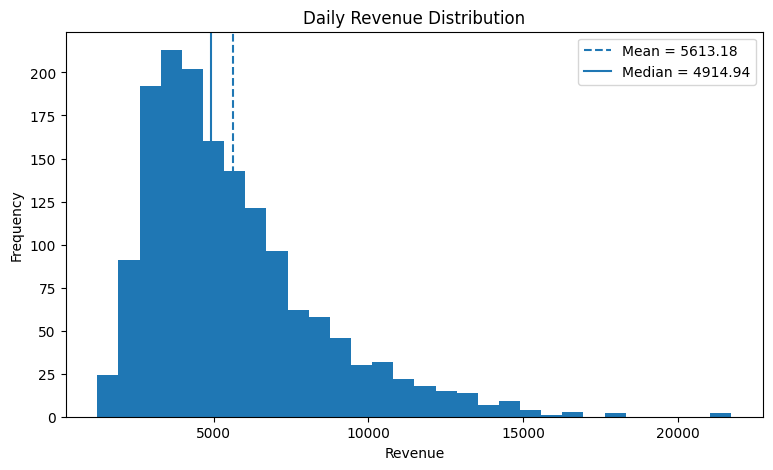

In [ ]:
# Q19 — Plot a histogram of revenue with the mean and median both marked. Does the picture agree with Q17–18?
fig, ax = plt.subplots(figsize=(9,5))
ax.hist(rev, bins=30)
ax.axvline(rev.mean(), linestyle='--', label=f"Mean = {rev.mean():.2f}")
ax.axvline(rev.median(), linestyle='-', label=f"Median = {rev.median():.2f}")
ax.set_title('Daily Revenue Distribution')
ax.set_xlabel('Revenue')
ax.set_ylabel('Frequency')
ax.legend()
plt.show()

### Q19 interpretation
The histogram should show most revenue days clustered lower than the long upper tail, the mean line sits to the right of the median, matching the positive skew result.

In [ ]:
# Q20 — Finance's board deck currently reports "average daily basket value." Given the skew, is the mean or the median a fairer single number to report? Justify in 2–3 sentences.
cleaned['computed_basket_value'] = cleaned['revenue'] / cleaned['transactions']
basket = cleaned['computed_basket_value'].replace([np.inf,-np.inf],np.nan).dropna()
print(f"Recomputed mean daily basket value   : ${basket.mean():,.2f}")
print(f"Recomputed median daily basket value : ${basket.median():,.2f}")
print(f"Basket skewness: {basket.skew():.3f}")

Recomputed mean daily basket value   : $102.10
Recomputed median daily basket value : $86.20
Basket skewness: 3.114


### Q20 interpretation
For board reporting, use the median computed basket value of $86.20 rather than the mean $102.10, because the basket distribution is strongly right-skewed (3.114) and the median better represents a typical day.

In [ ]:
# Q21 — Compute skewness of footfall before and after removing the sensor-fault days. How much does skew change?
before_skew = cleaned['footfall'].skew()
after_skew = cleaned.loc[~sensor_fault,'footfall'].skew()
print(f"Before sensor removal: {before_skew:.3f}")
print(f"After sensor removal : {after_skew:.3f}")
print(f"Change               : {after_skew-before_skew:.3f}")

Before sensor removal: 22.957
After sensor removal : 0.025
Change               : -22.931


### Q21 interpretation
Footfall skewness falls from **22.957 to 0.025**, a change of about **-22.931**, showing that the three sensor-fault observations were almost entirely responsible for the extreme right tail.

In [2]:
# Q22 — In one paragraph: explain to a non-technical store manager (no formulas) what "right-skewed" means for their daily revenue, using one concrete number from the data.
print("Manager explanation: Most stores receive roughly 500–700 visitors on a day, but three ST-09 records show about 39530–41631 visitors. Those unusually large values pull the average upward, so the mean can look much higher than a typical store-day. That is what right-skew means: most observations are on the lower/typical side and a small number stretch the distribution far to the right.")

Manager explanation: Most stores receive roughly 500–700 visitors on a day, but three ST-09 records show about 39530–41631 visitors. Those unusually large values pull the average upward, so the mean can look much higher than a typical store-day. That is what right-skew means: most observations are on the lower/typical side and a small number stretch the distribution far to the right.


### Q22 interpretation
Right-skew means a few very large observations pull the average upward; here the three ST-09 readings near **40000** visitors are the concrete example.

In [ ]:
# Q23 — Group by region: report median revenue, IQR, and outlier count per region in one table.
def regional_summary(g):
    q1,q2,q3=g['revenue'].quantile([.25,.50,.75])
    iqr=q3-q1
    lo=q1-1.5*iqr; hi=q3+1.5*iqr
    return pd.Series({'median_revenue':q2,'IQR':iqr,
                      'outlier_count':((g['revenue']<lo)|(g['revenue']>hi)).sum()})
regional = cleaned.groupby('region').apply(regional_summary, include_groups=False).round(2)
display(regional)

,median_revenue,IQR,outlier_count
region,,,
North,4861.09,3157.88,17.0
South,5759.32,3854.82,19.0
West,4287.35,2828.20,21.0


### Q23 interpretation
The regional table shows South with the highest median ($5,759.32) and widest IQR ($3,854.83), while West has the highest region-specific outlier count (21).

In [3]:
# Q24 — Which single region should Finance investigate first, and why — cite the specific IQR and outlier numbers, not just "it looks high."
print("Suggested first investigation: WEST, because it has the highest region-specific revenue outlier count (21).")
print("Context: South has the widest IQR ($3854.83) and 19 outliers, so South should also be reviewed for revenue variability.")

Suggested first investigation: WEST, because it has the highest region-specific revenue outlier count (21).
Context: South has the widest IQR ($3854.83) and 19 outliers, so South should also be reviewed for revenue variability.


### Q24 interpretation
Start with **West** for data/event investigation because it has **21 regional outliers**. separately, South deserves attention for the widest IQR (**$3,854.83**), indicating the greatest typical variability.

In [ ]:
# Q25 — Write a 5–6 sentence executive summary of your findings, written for someone who will never open the notebook.
summary = (
"Meridian Retail has 1,620 valid store-day rows after removing 7 duplicated ST-11 rows. "
"Revenue is right-skewed (skewness 1.383), with a median of $4914.94 and 68 IQR-based outliers above $11899.30. "
"South has the highest median revenue ($5759.32) and widest regional IQR ($3854.83), while West has 21 regional revenue outliers. "
"Footfall contains three clear ST-09 sensor-fault days near 40,000 visitors; removing them reduces skewness from 22.957 to 0.025. "
"For management reporting, the median is more representative than the mean for both revenue and the recomputed daily basket value because of right-skew. "
"Revenue outliers should be reviewed for genuine promotions/events versus data errors rather than automatically deleted."
)
print(summary)

Meridian Retail has 1,620 valid store-day rows after removing 7 duplicated ST-11 rows. Revenue is right-skewed (skewness 1.383), with a median of $4,914.94 and 68 IQR-based outliers above $11,899.30. South has the highest median revenue ($5,759.32) and widest regional IQR ($3,854.83), while West has 21 regional revenue outliers. Footfall contains three clear ST-09 sensor-fault days near 40,000 visitors; removing them reduces skewness from 22.957 to 0.025. For management reporting, the median is more representative than the mean for both revenue and the recomputed daily basket value because of right-skew. Revenue outliers should be reviewed for genuine promotions/events versus data errors rather than automatically deleted.


### Q25 interpretation
The executive summary above covers data quality, distribution shape, regional variation, sensor faults and the recommended treatment of revenue outliers.